In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [7]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'package(in lpa)')

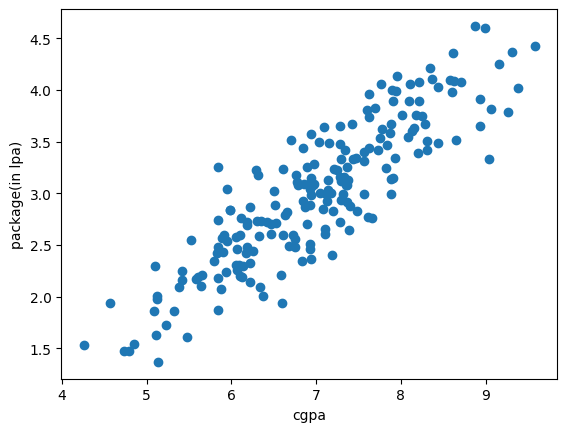

In [8]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('cgpa')
plt.ylabel('package(in lpa)')

In [9]:
X=df.iloc[:,0:1]
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [10]:
Y = df.iloc[:,-1]
Y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

In [12]:
lr = LinearRegression()

In [13]:
lr.fit(X_train, Y_train)

LinearRegression()

In [14]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [15]:
Y_test

,package
112,4.10
29,3.49
182,2.08
199,2.33
193,1.94
85,1.48
10,1.86
54,3.09
115,4.21
35,2.87


In [16]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

In [17]:
y_pred = lr.predict(X_test)
y_pred

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

Text(0, 0.5, 'package(in lpa)')

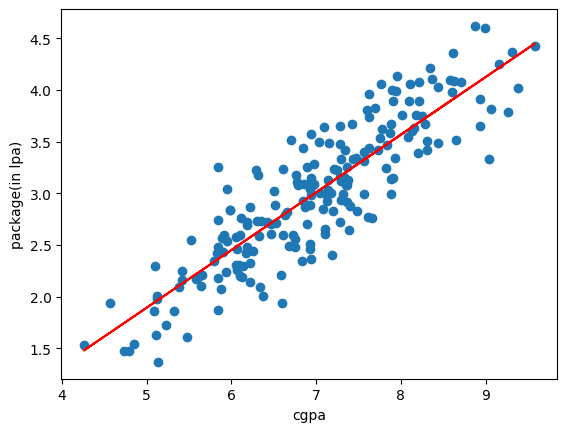

In [18]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('cgpa')
plt.ylabel('package(in lpa)')

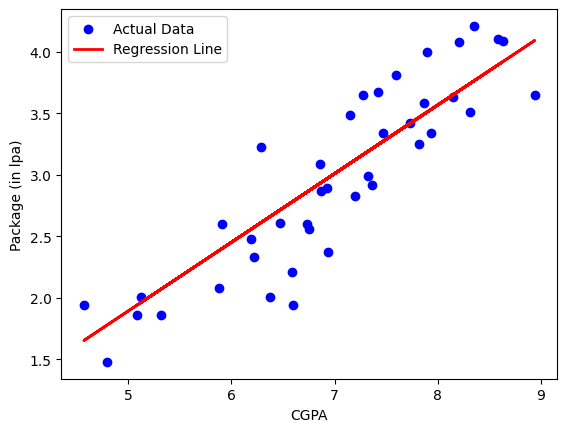

In [19]:
plt.scatter(X_test, Y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('CGPA')
plt.ylabel('Package (in lpa)')
plt.legend()
plt.show()

In [20]:
w = lr.coef_
w

array([0.55795197])

In [21]:
b = lr.intercept_
b

np.float64(-0.8961119222429144)

In [22]:
# y = w*x + b

w * 8.58 + b

array([3.89111601])

In [23]:
# It can also predict package for the cgpa that is not there in data

w * 9.5 + b

array([4.40443183])

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
y_pred = lr.predict(X_test)

In [31]:
Y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [35]:
# in LPA
print("MAE", mean_absolute_error(y_pred, Y_test))

MAE 0.2884710931878175


In [33]:
print("MSE", mean_squared_error(y_pred, Y_test))

MSE 0.12129235313495527


In [36]:
# in LPA
print("RMSE",np.sqrt(mean_squared_error(y_pred, Y_test)))

RMSE 0.34827051717731616


In [38]:
print("R2", r2_score(y_pred, Y_test))

R2 0.6626575570753073


In [40]:
X_test.shape

(40, 1)

In [41]:
# Adjusted R2

r2 = r2_score(y_pred, Y_test)

1 - ((1-r2)*(40-1))/(40-1-1)

0.6537801243667627

## Adding a Irrelevant Column

In [42]:
new_df = df.copy()
new_df['random_feature'] = np.random.random(200)

new_df = new_df[['cgpa','random_feature','package']]
new_df.head()

,cgpa,random_feature,package
0,6.89,0.826303,3.26
1,5.12,0.691308,1.98
2,7.82,0.755148,3.25
3,7.42,0.418548,3.67
4,6.94,0.507551,3.57


Text(0, 0.5, 'package(in lpa)')

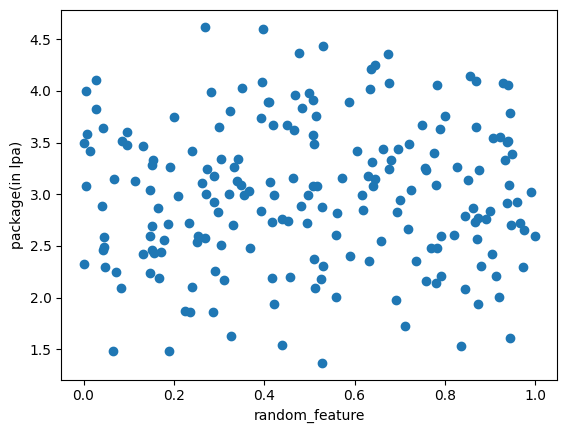

In [43]:
plt.scatter(new_df['random_feature'],new_df['package'])
plt.xlabel('random_feature')
plt.ylabel('package(in lpa)')

In [44]:
X = new_df.iloc[:,0:2]
Y = new_df.iloc[:,-1]

In [45]:
X

,cgpa,random_feature
0,6.89,0.826303
1,5.12,0.691308
2,7.82,0.755148
3,7.42,0.418548
4,6.94,0.507551
...,...,...
195,6.93,0.042241
196,5.89,0.870195
197,7.21,0.272857
198,7.63,0.469164


In [46]:
Y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [47]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [48]:
lr = LinearRegression()

In [49]:
lr.fit(X_train, Y_train)

LinearRegression()

In [61]:
Y_pred = lr.predict(X_test)

In [62]:
Y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [64]:
print("R2", r2_score(Y_pred, Y_test))

R2 0.6764961667331


In [66]:
r2 = r2_score(Y_pred, Y_test)

1 - ((1-r2)*(40-1))/(40-1-2)

0.6590094730429973

## Adding a Relevant Column

In [54]:
new_df2 = df.copy()
new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]
new_df2.head()

,cgpa,iq,package
0,6.89,2.16,3.26
1,5.12,1.58,1.98
2,7.82,2.75,3.25
3,7.42,2.77,3.67
4,6.94,2.47,3.57


Text(0, 0.5, 'package(in lpa)')

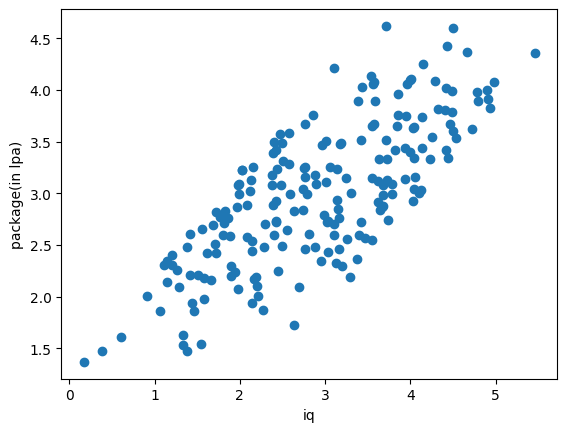

In [55]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('package(in lpa)')

In [76]:
X = new_df2.iloc[:,0:2]
Y = new_df2.iloc[:,-1]

In [77]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [78]:
lr = LinearRegression()

In [79]:
lr.fit(X_train, Y_train)

LinearRegression()

In [80]:
Y_pred = lr.predict(X_test)

In [81]:
print("R2", r2_score(Y_pred, Y_test))

R2 0.7161333177267606


In [82]:
r2 = r2_score(Y_pred, Y_test)

1 - ((1-r2)*(40-1))/(40-1-2)

0.7007891727390179